In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import helpers
path = os.getcwd()
train_path = path + r"\data\train.parquet"
test_path = path + r"\data\test.parquet"
sensors_path = path + r"\data\sensors.parquet"


train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)
sensors = pd.read_parquet(sensors_path)

In [78]:
train = train.copy()

In [79]:
train.tail(10)

,sensor,time,power,temperature
6626918,N96,7.876138e+09,0.0,17.286369
6626919,N96,7.877002e+09,0.0,17.306267
6626920,N96,7.877866e+09,0.0,17.084299
6626921,N96,7.878730e+09,0.0,17.013214
6626922,N96,7.879594e+09,0.0,17.587847
6626923,N96,7.880458e+09,0.0,16.284252
6626924,N96,7.881322e+09,0.0,NaN
6626925,N96,7.882186e+09,0.0,16.588602
6626926,N96,7.883050e+09,0.0,16.201292
6626927,N96,7.884000e+09,0.0,17.525541


In [80]:
train.shape

(6626928, 4)

<Axes: xlabel='coor_x', ylabel='coor_y'>

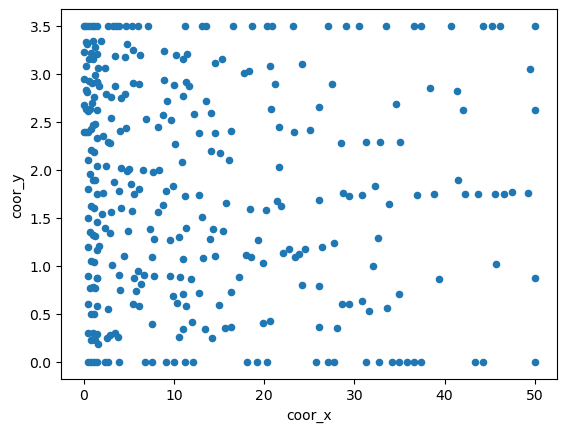

In [81]:
sensors.plot(kind='scatter', x='coor_x', y='coor_y')

<Axes: xlabel='time', ylabel='power'>

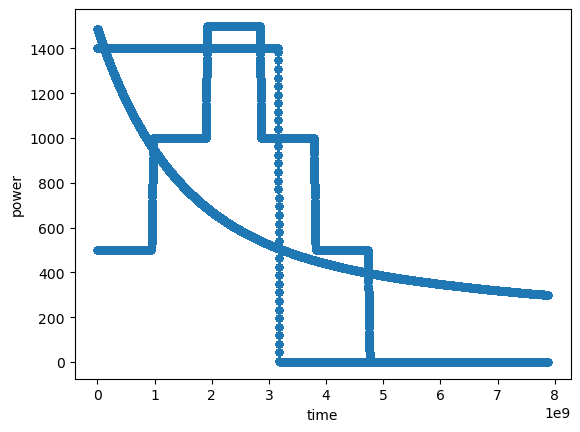

In [82]:
train.plot(kind='scatter', x='time', y='power')

<Axes: xlabel='time', ylabel='temperature'>

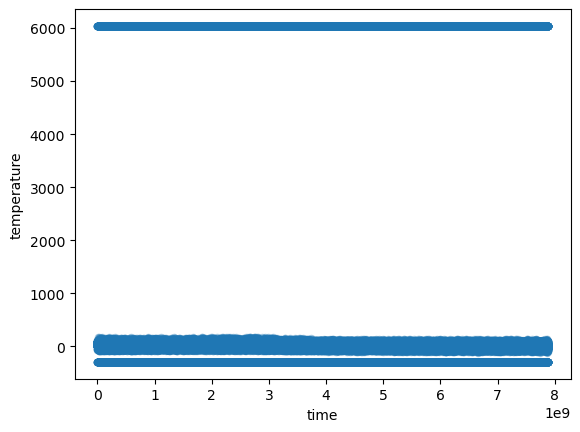

In [83]:
train.plot(kind='scatter', x='time', y='temperature', alpha=0.3)

<Axes: xlabel='sensor', ylabel='temperature'>

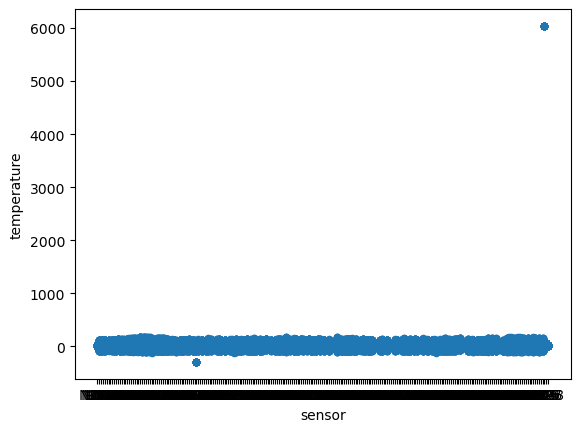

In [84]:
#view of possible outliers --> here we see two 'bad' sensors
train.plot(kind='scatter', x='sensor', y='temperature')

In [85]:
train.describe(include="all")

,sensor,time,power,temperature
count,6626928,6.626928e+06,6.626928e+06,6.527525e+06
unique,242,NaN,NaN,NaN
top,N102,NaN,NaN,NaN
freq,27384,NaN,NaN,NaN
mean,NaN,3.942130e+09,5.549463e+02,4.706070e+01
std,NaN,2.275997e+09,5.258427e+02,3.897674e+02
min,NaN,0.000000e+00,0.000000e+00,-2.921508e+02
25%,NaN,1.971605e+09,0.000000e+00,1.566275e+01
50%,NaN,3.942432e+09,4.445813e+02,1.939439e+01
75%,NaN,5.913173e+09,1.000000e+03,2.877052e+01


In [86]:
#see if we have missing values --> some in temperature
train.isna().any()

sensor         False
time           False
power          False
temperature     True
dtype: bool

In [87]:
#visualise how many missing values
missing_idx = train[train['temperature'].isna()].index
print(missing_idx)
print(len(missing_idx))

Index([    106,     364,     477,     501,     568,     657,     712,     769,
           833,     870,
       ...
       6626263, 6626302, 6626312, 6626504, 6626575, 6626627, 6626671, 6626726,
       6626890, 6626924],
      dtype='int64', length=99403)
99403


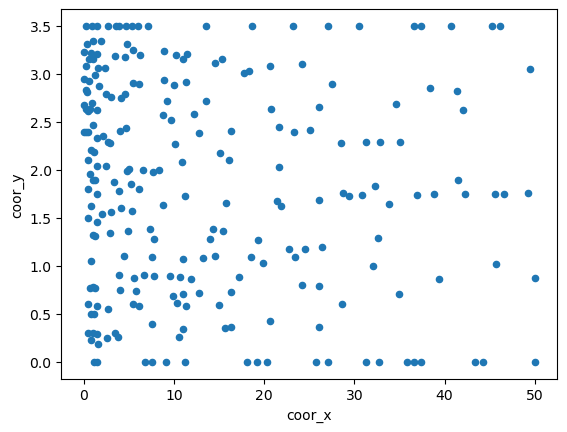

In [88]:
#see where the missing values are --> a bit everywhere, which doesn't help us much 
sensors_misval = train.loc[missing_idx, 'sensor'].unique()
sensors_misval_coords = sensors[sensors['sensor'].isin(sensors_misval)]

sensors_misval_coords.plot(kind='scatter', x='coor_x', y='coor_y')
plt.show()

In [89]:
#fills the missing temperature by using interpolate because our data is ordered chronologically 
#and taking into account ouly values from the same sensor
train['temperature'] = (
    train.groupby('sensor')['temperature']
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

In [90]:
#control that every missing values are replaced
train.isna().any() 

sensor         False
time           False
power          False
temperature    False
dtype: bool

In [91]:
#finding the number of the two sensors which are very far from our expected values; outliers
neg_outlier = train[train['temperature'] == train['temperature'].min()]
pos_outlier = train[train['temperature'] == train['temperature'].max()]
print(neg_outlier['sensor'], pos_outlier['sensor'])

483784     N277
483785     N277
483786     N277
483787     N277
483788     N277
           ... 
4910859    N277
4910860    N277
4910861    N277
4910862    N277
4910863    N277
Name: sensor, Length: 27384, dtype: category
Categories (242, str): ['N102', 'N103', 'N108', 'N112', ..., 'N926', 'N927', 'N928', 'N96'] 2181592    N927
2181593    N927
2181594    N927
2181595    N927
2181596    N927
           ... 
6608667    N927
6608668    N927
6608669    N927
6608670    N927
6608671    N927
Name: sensor, Length: 27384, dtype: category
Categories (242, str): ['N102', 'N103', 'N108', 'N112', ..., 'N926', 'N927', 'N928', 'N96']


In [ ]:
#get rid of the outlier sensors
train = train[train["sensor"] != "N277"]
train = train[train["sensor"] != "N927"]
sensors = sensors[sensors["sensor"] != "N277"]
sensors = sensors[sensors["sensor"] != "N927"]

In [93]:
#verify that the outlier sensors are gone
np.all(train["sensor"] != 'N277') and np.all(train["sensor"] != 'N927')

np.True_

<Axes: xlabel='sensor', ylabel='temperature'>

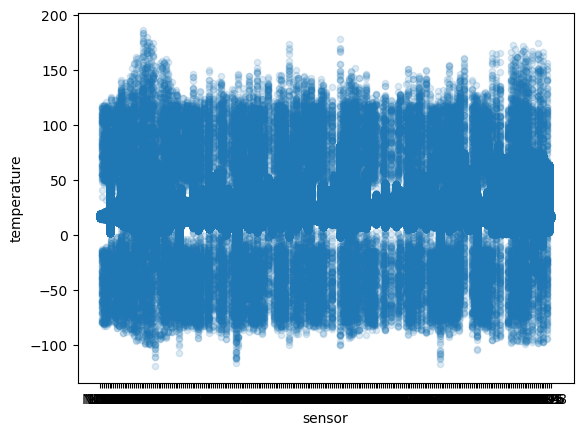

In [ ]:
#temperatures per sensors after getting rid of the two bad sensors
train.plot(kind='scatter', x='sensor', y='temperature', alpha=0.15)

(2190720, 4) (2190720, 4) (2190720, 4)


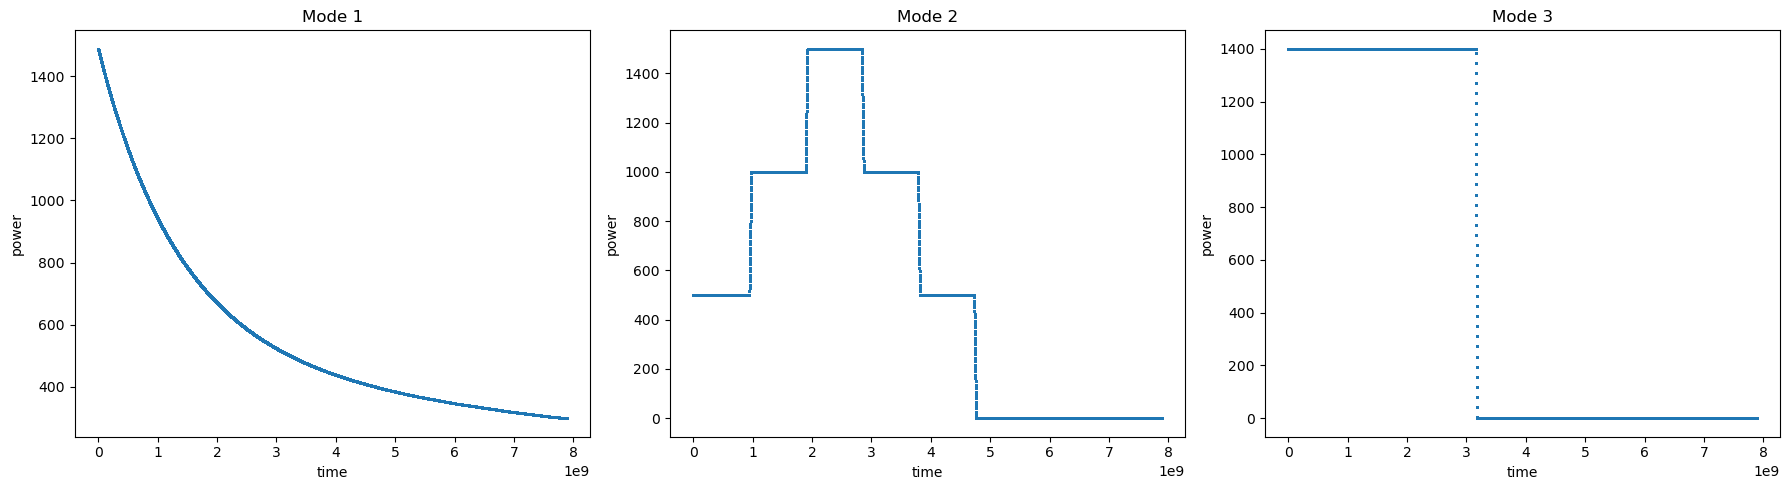

In [96]:
#separate out three modes so that we can try different models for different modes
BLOCK = len(train) // 3

mode1 = train.iloc[0       : BLOCK].copy()
mode2 = train.iloc[BLOCK   : 2*BLOCK].copy()
mode3 = train.iloc[2*BLOCK :].copy()

# Vérification
print(mode1.shape, mode2.shape, mode3.shape)

# Visualiser les 3 modes séparément
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mode1.plot(kind='scatter', x='time', y='power', ax=axes[0], title='Mode 1', s=1)
mode2.plot(kind='scatter', x='time', y='power', ax=axes[1], title='Mode 2', s=1)
mode3.plot(kind='scatter', x='time', y='power', ax=axes[2], title='Mode 3', s=1)

plt.tight_layout()
plt.show()